# Task 1: Data Analysis
## Setup

In [45]:
import pandas as pd
import numpy as np

df = pd.read_csv('spiff_data-2.csv', index_col=0)
cols = ['gurkor','guitars','slingshots','stocks','sugar','water','tranquillity']

# Remove spikes
for col in cols:
    df.loc[df[col] > 100, col] = np.nan

## Raw price series
Plot all seven series to get an initial feel for the data — trends, scale differences, and any anomalies.

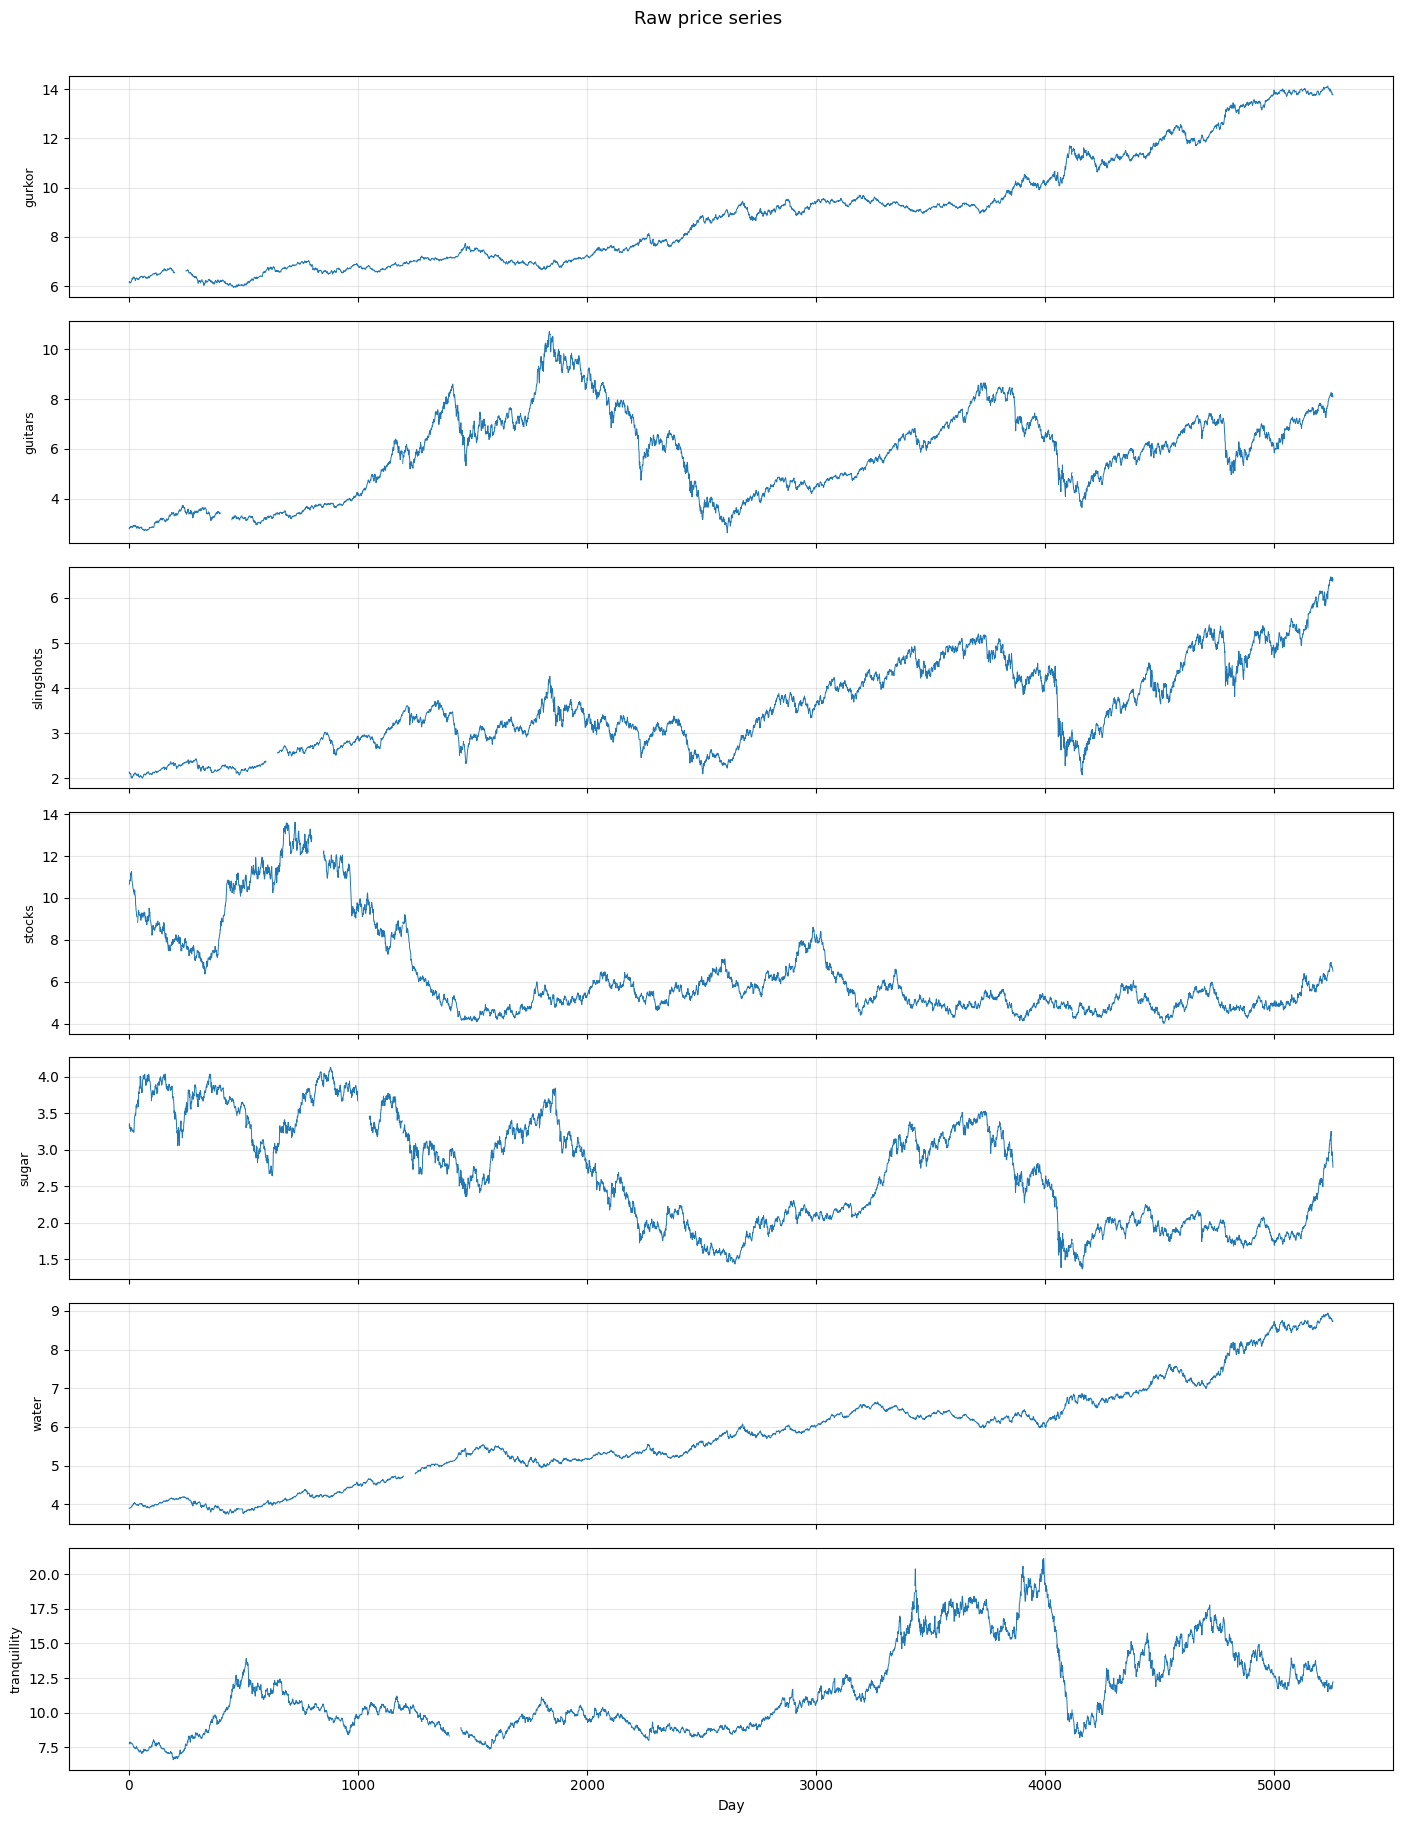

In [46]:
fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True)

for ax, col in zip(axes, cols):
    ax.plot(df['day'], df[col], linewidth=0.7)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Day')
fig.suptitle('Raw price series', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The spikes to 1000 are clearly visible across all series and occur at the same points in time — 
likely data entry errors rather than real market events. We cap the y-axis to see the underlying dynamics.

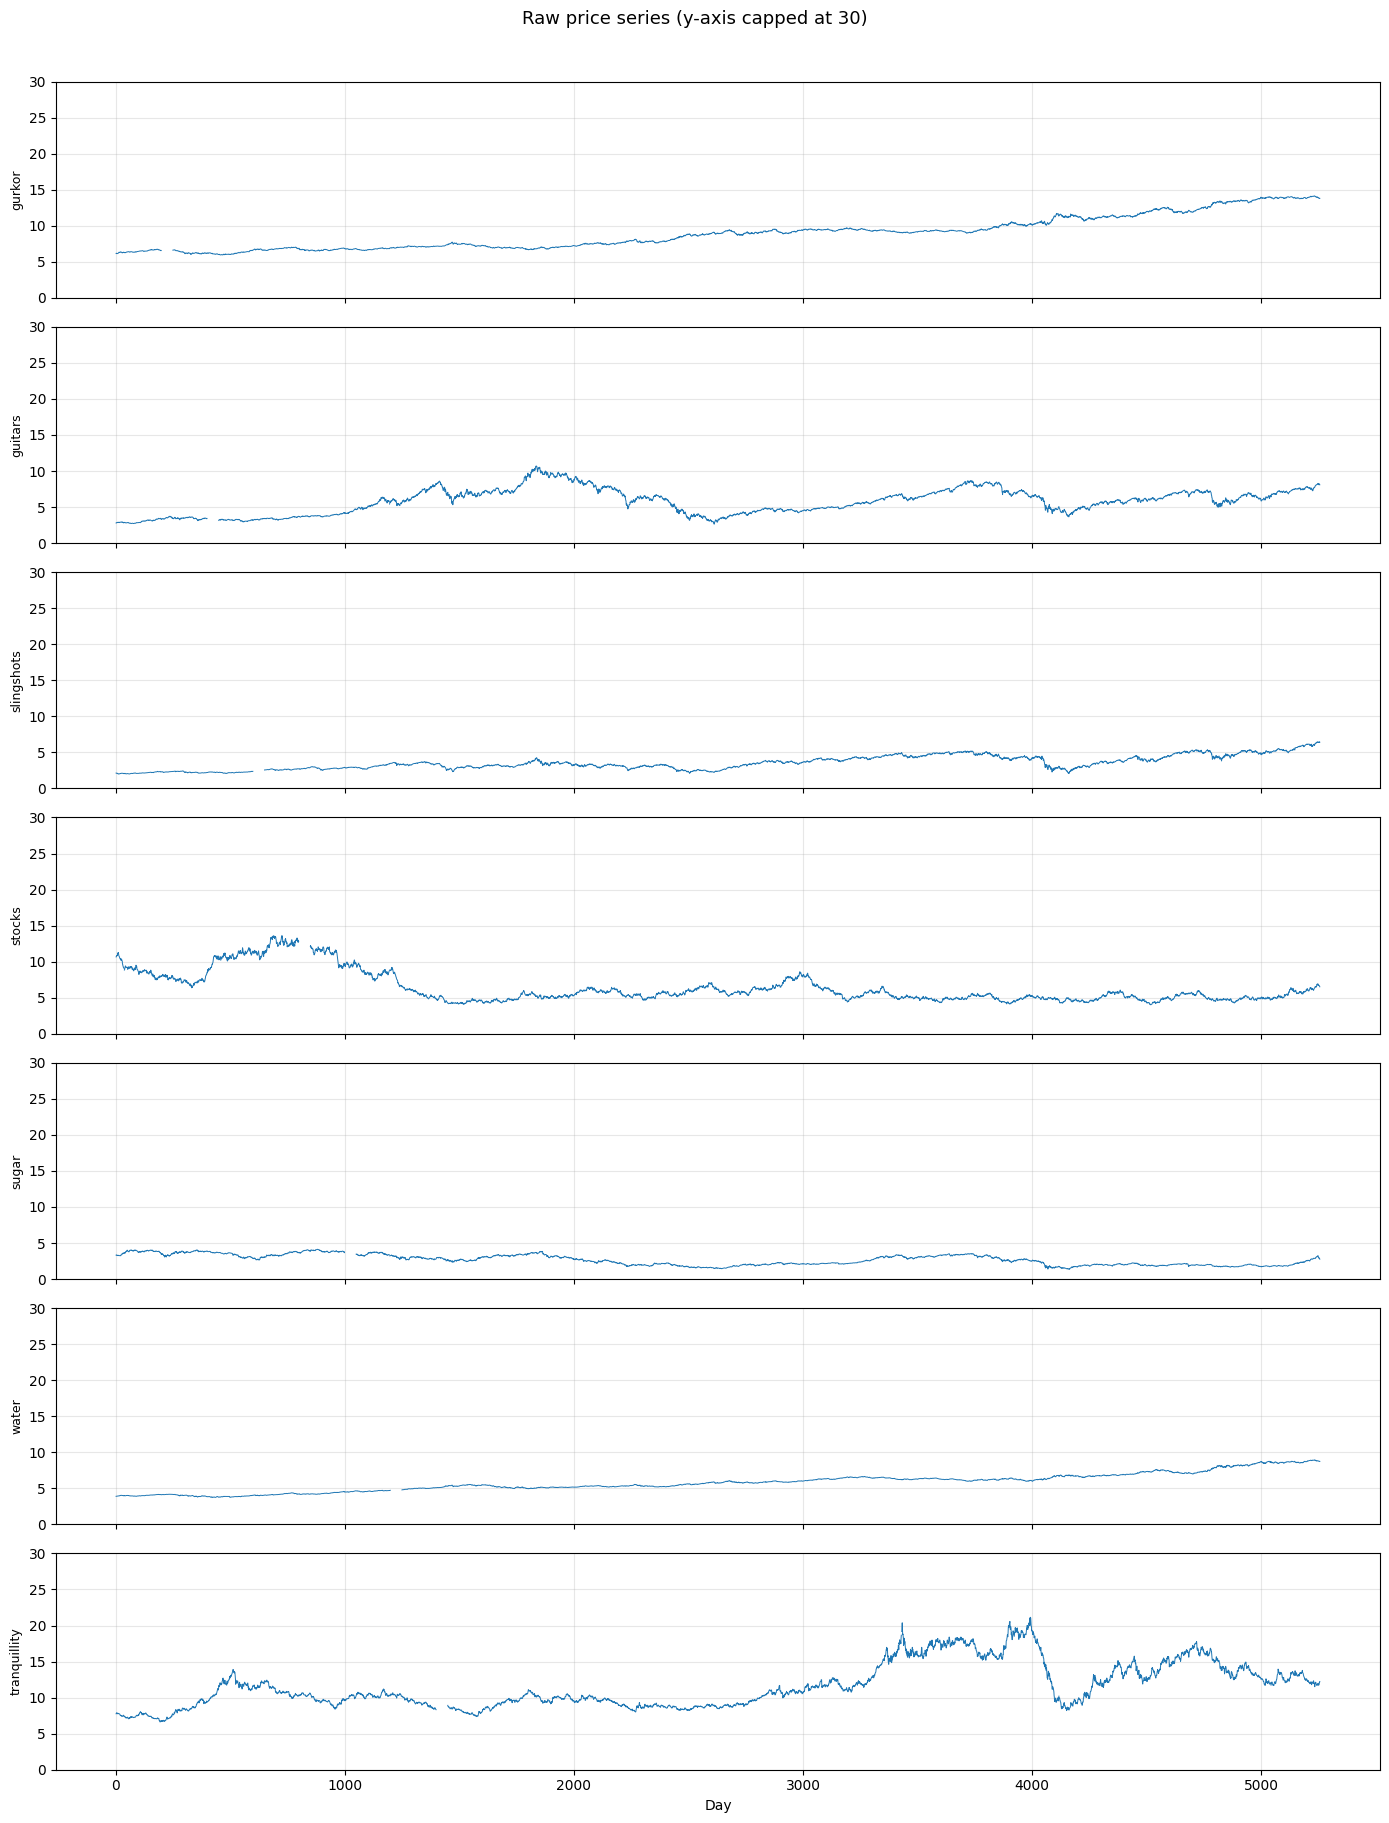

In [42]:
fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True)

for ax, col in zip(axes, cols):
    ax.plot(df['day'], df[col], linewidth=0.7)
    ax.set_ylabel(col, fontsize=9)
    ax.set_ylim(0, 30)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Day')
fig.suptitle('Raw price series (y-axis capped at 30)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Data cleaning
The spikes (value = 1000) occur simultaneously across all series at the same 5 days. 
We replace them with NaN before any further analysis.

In [47]:
'''# Replace spikes with NaN
for col in cols:
    df.loc[df[col] > 100, col] = np.nan'''

# Confirm spikes are gone
print("Max values after cleaning:")
print(df[cols].max().round(3))

Max values after cleaning:
gurkor          14.132
guitars         10.719
slingshots       6.469
stocks          13.613
sugar            4.125
water            8.949
tranquillity    21.138
dtype: float64


## Log-returns
We work with log-returns rather than price levels. Price levels are non-stationary (they trend), 
while log-returns are stationary and better suited for statistical analysis.

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$

In [35]:
log_ret = pd.DataFrame(index=df.index)

for col in cols:
    log_ret[col] = np.log(df[col]).diff()

print("Log-return summary statistics:")
log_ret[cols].describe().round(5)

Log-return summary statistics:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5194.00000,5194.00000,5194.00000,5194.00000,5194.00000,5194.00000,5194.00000
mean,0.00016,0.00024,0.00019,-0.00007,-0.00001,0.00015,0.00008
std,0.00394,0.01488,0.01475,0.01494,0.01521,0.00351,0.01259
min,-0.02484,-0.09306,-0.12190,-0.06047,-0.14124,-0.02613,-0.08669
25%,-0.00199,-0.00661,-0.00653,-0.00996,-0.00750,-0.00175,-0.00676
50%,0.00000,0.00054,0.00046,0.00016,0.00000,0.00009,0.00000
75%,0.00244,0.00748,0.00749,0.01031,0.00778,0.00219,0.00704
max,0.03628,0.12253,0.09250,0.05170,0.18916,0.01733,0.05977


## Log-return series
Plotting the returns reveals volatility clustering — periods of large moves tend to cluster together.
Note that `gurkor` and `water` are visibly less volatile than the others.

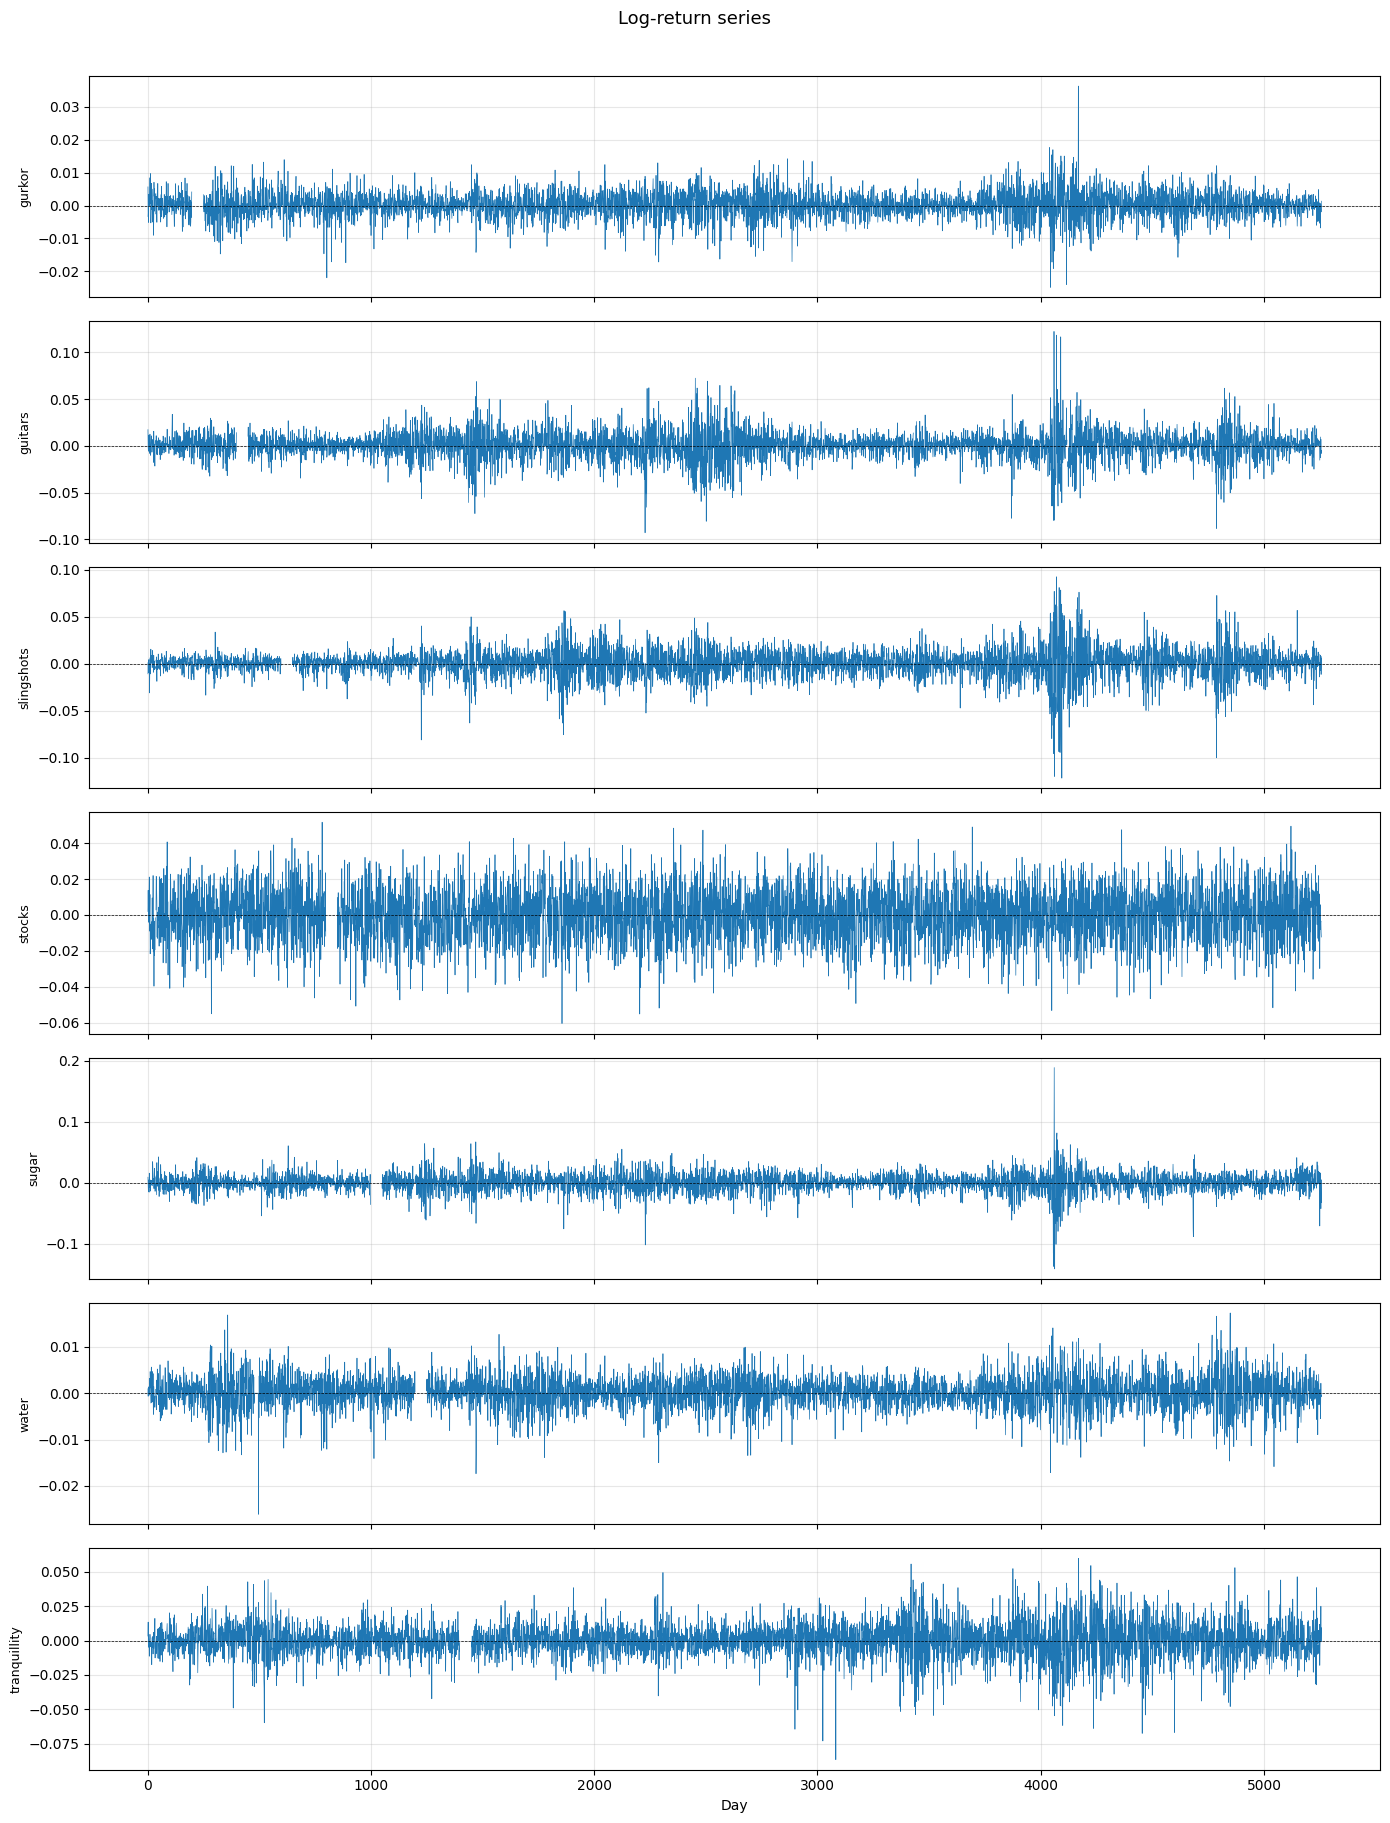

In [36]:
fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True)

for ax, col in zip(axes, cols):
    ax.plot(df['day'], log_ret[col], linewidth=0.5)
    ax.set_ylabel(col, fontsize=9)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Day')
fig.suptitle('Log-return series', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Correlation matrix
Correlation between log-returns tells us which series move together. 
This is directly useful for Task 2 — correlated series can help fill each other's gaps.

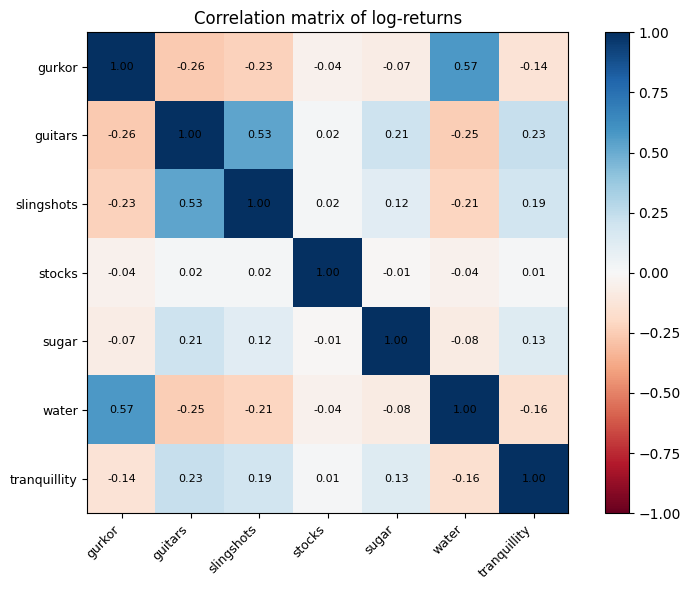

In [37]:
corr = log_ret[cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cols, fontsize=9)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

ax.set_title('Correlation matrix of log-returns')
plt.tight_layout()
plt.show()

Key observations from the correlation matrix:
- **gurkor** and **water** are strongly positively correlated (+0.58)
- **guitars** and **slingshots** are strongly positively correlated (+0.53)
- **stocks** is essentially uncorrelated with everything (max |r| ≈ 0.04)
- The two groups are negatively correlated with each other (~-0.23)

This suggests three natural groups:
- Group A (low volatility): `gurkor`, `water`
- Group B (high volatility): `guitars`, `slingshots`
- Group C (independent): `stocks`

## Stationarity — ADF test
We test each series for a unit root using the Augmented Dickey-Fuller test.
- Price levels are expected to be **non-stationary** (fail to reject unit root)
- Log-returns are expected to be **stationary** (reject unit root)

In [38]:
from statsmodels.tsa.stattools import adfuller

print(f"{'Series':<15} {'Price p-value':>15} {'Returns p-value':>16} {'Returns stationary?':>20}")
print("-" * 70)

for col in cols:
    p_price   = adfuller(df[col].dropna())[1]
    p_returns = adfuller(log_ret[col].dropna())[1]
    stationary = "YES" if p_returns < 0.05 else "NO"
    print(f"{col:<15} {p_price:>15.4f} {p_returns:>16.4f} {stationary:>20}")

Series            Price p-value  Returns p-value  Returns stationary?
----------------------------------------------------------------------
gurkor                   0.9905           0.0000                  YES
guitars                  0.2646           0.0000                  YES
slingshots               0.7803           0.0000                  YES
stocks                   0.1718           0.0000                  YES
sugar                    0.3219           0.0000                  YES
water                    0.9914           0.0000                  YES
tranquillity             0.1916           0.0000                  YES


## Rolling volatility
A 60-day rolling standard deviation of log-returns shows how volatility evolves over time.
Periods of elevated volatility are clearly visible, and confirm that `gurkor` and `water` 
operate in a much calmer volatility regime than the rest.

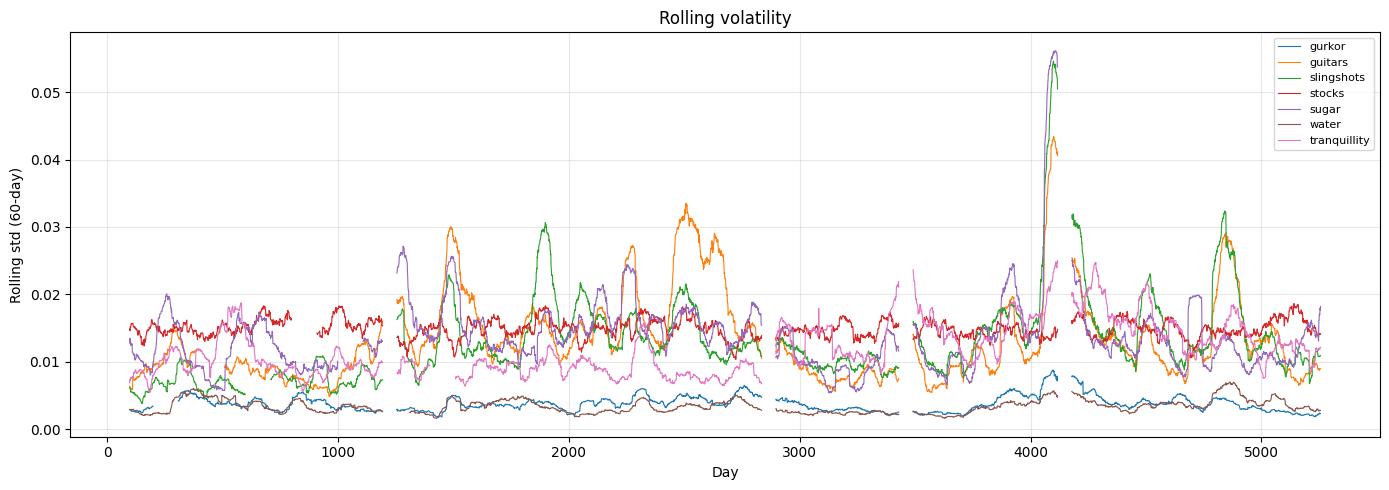

In [39]:
fig, ax = plt.subplots(figsize=(14, 5))

for col in cols:
    rolling_vol = log_ret[col].rolling(60).std()
    ax.plot(df['day'], rolling_vol, linewidth=0.8, label=col)

ax.set_xlabel('Day')
ax.set_ylabel('Rolling std (60-day)')
ax.set_title('Rolling volatility')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ACF and PACF of log-returns
The autocorrelation function (ACF) and partial ACF (PACF) of returns should show little 
to no autocorrelation — consistent with an efficient market. However, the **squared returns** 
($r_t^2$) often show significant autocorrelation, indicating volatility clustering (ARCH effects).

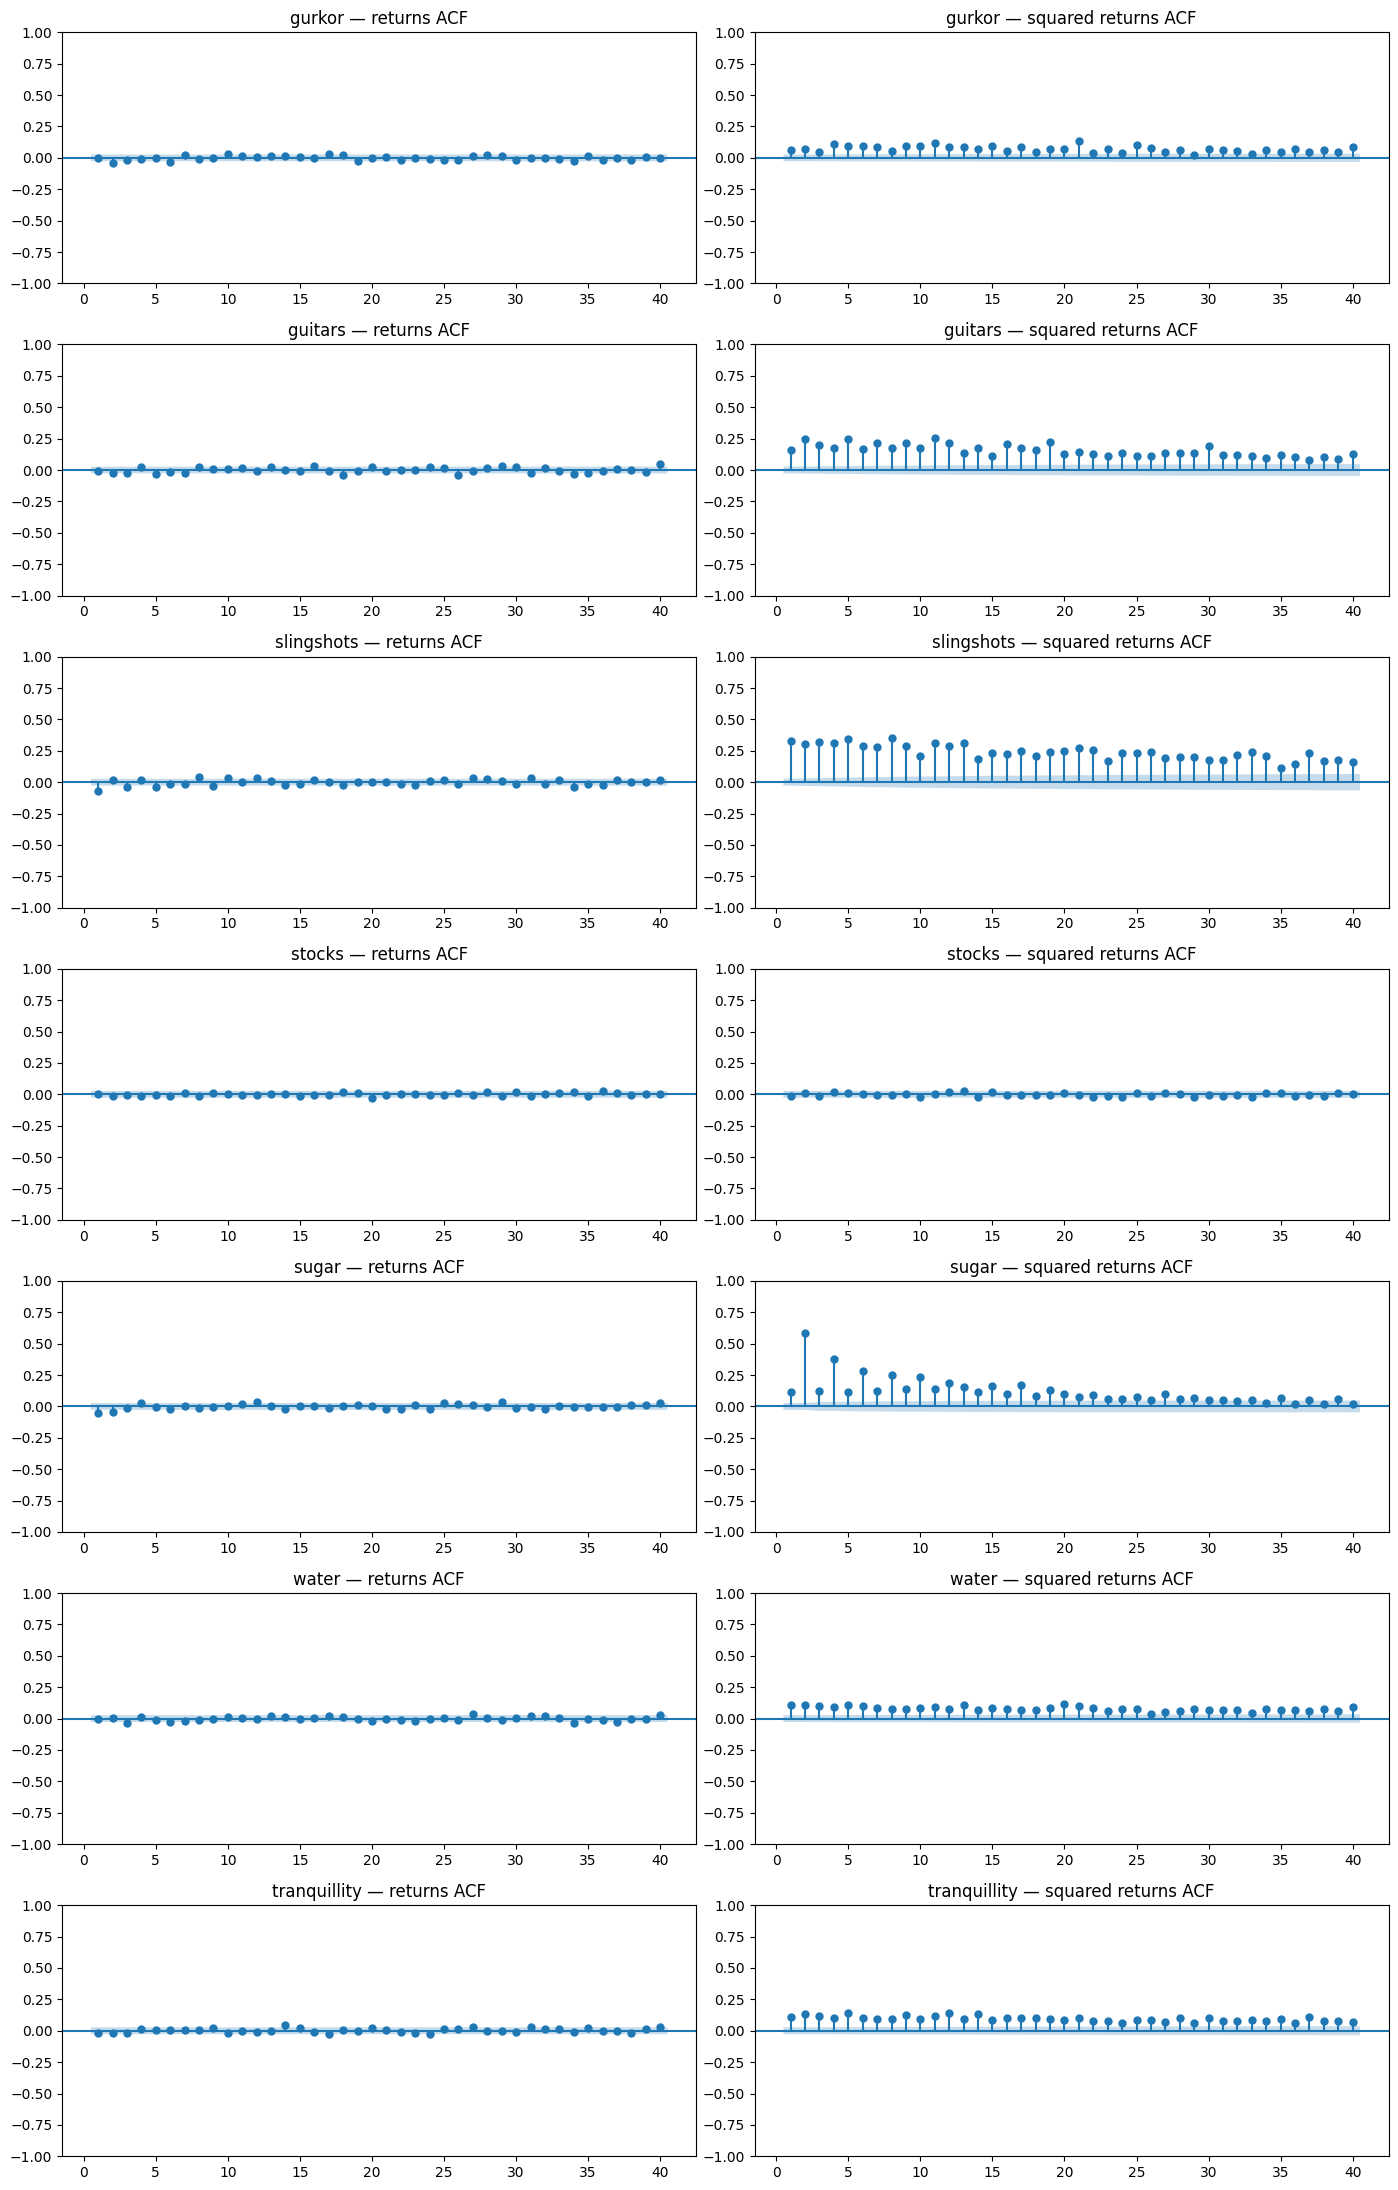

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(len(cols), 2, figsize=(14, 22))

for i, col in enumerate(cols):
    r = log_ret[col].dropna()
    plot_acf(r,    ax=axes[i, 0], lags=40, title=f'{col} — returns ACF',         zero=False)
    plot_acf(r**2, ax=axes[i, 1], lags=40, title=f'{col} — squared returns ACF', zero=False)

plt.tight_layout()
plt.show()

## Summary of findings

| Series | Avg daily return | Daily vol | Notable correlations |
|---|---|---|---|
| gurkor | +0.016% | 0.39% | +0.58 with water |
| guitars | +0.024% | 1.49% | +0.53 with slingshots |
| slingshots | +0.019% | 1.48% | +0.53 with guitars |
| stocks | −0.007% | 1.49% | uncorrelated with all |
| sugar | −0.001% | 1.52% | weakly positive with guitars |
| water | +0.015% | 0.35% | +0.58 with gurkor |
| tranquillity | +0.008% | 1.26% | weakly positive with guitars |

**Key takeaways for Tasks 2 and 3:**
- Work in log-return space — price levels are non-stationary
- The correlation structure can be exploited for interpolation (Task 2)
- `gurkor`/`water` and `guitars`/`slingshots` behave as pairs — models can leverage this
- `stocks` must be modelled independently